In [1]:
import matplotlib.pyplot as plt
import numpy as np

from MCTDHF_direct_jax import *

import jax.numpy as jnp
from jax import jit

from integrators import *

import sys
sys.path.insert(0, '..')
from electron_integrals import *
sys.path.remove('..')

Define number of electrons and orbitals

In [11]:
# Number of spatial orbitals
num_spatial_orbitals = 21
# Number of electrons
num_alpha_electrons = 1
num_beta_electrons = 1
# Number of MCTDHF orbitals
num_mctdhf_orbitals = 6
num_states=10

Calculate electron integrals

In [3]:
# Finite-Difference (same parameters as in Zhangellini)
x = np.linspace(-10, 10, 201)
pot = HOPotential(0.25)

spf, h = get_spf_and_diag_h(num_spatial_orbitals, x, pot)
g = coulomb_interaction_matrix_elements(spf, spf, x, x, kappa = 1, a = 0.25)

def get_MCTDHF(h, ht, g, num_mctdhf_orbitals, num_spatial_orbitals, 
                 num_alpha_electrons, num_beta_electrons, num_states=1, imag_time=False):

    return MCTDHF(h, ht, g, num_mctdhf_orbitals, num_spatial_orbitals, 
                  num_alpha_electrons, num_beta_electrons, num_states, imag_time)

In [3]:
# Sinc-DVR (Same parameters as in Zhangellini)

def kinetic_energy_mels(i, j, dx):
    with np.errstate(divide='ignore'):
        return np.where(
            i==j,
            np.pi ** 2 / (6 * dx ** 2),
            (-1.0) ** (i_min_j := i - j) / (dx ** 2 * i_min_j **2),
        )

grid = np.linspace(-10, 10, num_spatial_orbitals)
x = grid
dx = np.abs(grid[1] - grid[0])
inds=np.arange(len(grid))

pot = lambda x, omega=0.25: 0.5 * omega**2 * x ** 2

t = kinetic_energy_mels(inds[:, None], inds[None, :], dx)
h = t + np.diag(pot(grid))
g = shielded_coulomb(grid[:, None], grid[None, :], kappa=1, a=0.25)

def xi(i, grid=grid, dx=dx):
    return np.sinc(((grid-grid[i])/dx))/np.sqrt(dx)

spf = np.array([xi(i) for i in range(num_spatial_orbitals)])

def get_MCTDHF(h, ht, g, num_mctdhf_orbitals, num_spatial_orbitals, 
                 num_alpha_electrons, num_beta_electrons, num_states = 1, imag_time=False):

    return MCTDHF_sinc(h, ht, g, num_mctdhf_orbitals, num_spatial_orbitals, 
                  num_alpha_electrons, num_beta_electrons, num_states, imag_time)

Imaginary time propagation

In [6]:
def get_DOP_solver(rhs, dt):
    @jit
    def integrate(t, y, dt=dt, rhs=rhs):
        k1 = rhs(t, y)
        k2 = rhs(t + dt/5, y + dt*k1/5)
        k3 = rhs(t + dt*3/10, y + dt*(3*k1 + 9*k2)/40)
        k4 = rhs(t + dt*4/5, y + dt*(k1*44/45 - k2*56/15 + k3*32/9))
        k5 = rhs(t + dt*8/9, y + dt*(k1*19372/6561 - k2*25360/2187 + k3*64448/6561 - k4*212/729))
        k6 = rhs(t + dt, y + dt*(k1*9017/3168 - k2*355/33 + k3*46732/5247 + k4*49/176 - k5*5103/18656))
        k7 = rhs(t + dt, y + dt*(k1*35/384 + k3*500/1113 + k4*125/192 - k5*2187/6784 + k6*11/84))

        y = y + dt * (k1*5179/57600 + k3*7571/16695 + k4*393/640 - k5*92097/339200 + k6*187/2100 + k7/40)

        return t + dt, y

    return integrate

In [12]:
mctdhf = get_MCTDHF(h, lambda t: 0, g, num_mctdhf_orbitals, 
                num_spatial_orbitals, num_alpha_electrons, 
                num_beta_electrons, num_states, imag_time=True)

#integrator = get_DOP_solver(mctdhf, 1e-2)
integrator = get_runge_kutta_4_solver(mctdhf, 1e-2)
ts, Es, Cs, bs = mctdhf.integrate(integrator, num_steps = 3000)

Plot

In [5]:
def plot_Cbe(ts, Cs, bs, Es):
    fig, axs = plt.subplots(1, 3, figsize=(16,6))
    axs[0].plot(ts, np.real(Cs.reshape(Cs.shape[0],-1)))
    axs[0].set_title('Cs')
    axs[1].plot(ts, np.real(bs.reshape(-1, num_spatial_orbitals, num_mctdhf_orbitals)[:,:,0]))
    axs[1].set_title('bs')
    axs[2].plot(ts, np.real(Es))
    axs[2].semilogy()
    #axs[2].set_ylim([0,5])
    axs[2].set_title('E')
    
    plt.show()

In [48]:
## Test that the states are orthogonal

for i,C in enumerate(Cs[-1]):
    t = np.zeros(num_states, dtype=np.complex64)
    t[i] = 1
    t2 = mctdhf.calculate_overlap(bs[-1],Cs[-1],bs[-1],np.array([C]*num_states))
    np.testing.assert_allclose(t,t2, atol=1e-6)


Final energy: [0.8287339 +0.j 0.83366644+0.j 1.0950674 +0.j 1.0822024 +0.j
 1.286855  +0.j 1.299165  +0.j 1.3784609 +0.j 1.4382455 +0.j
 1.6120948 +0.j 1.6432868 +0.j]


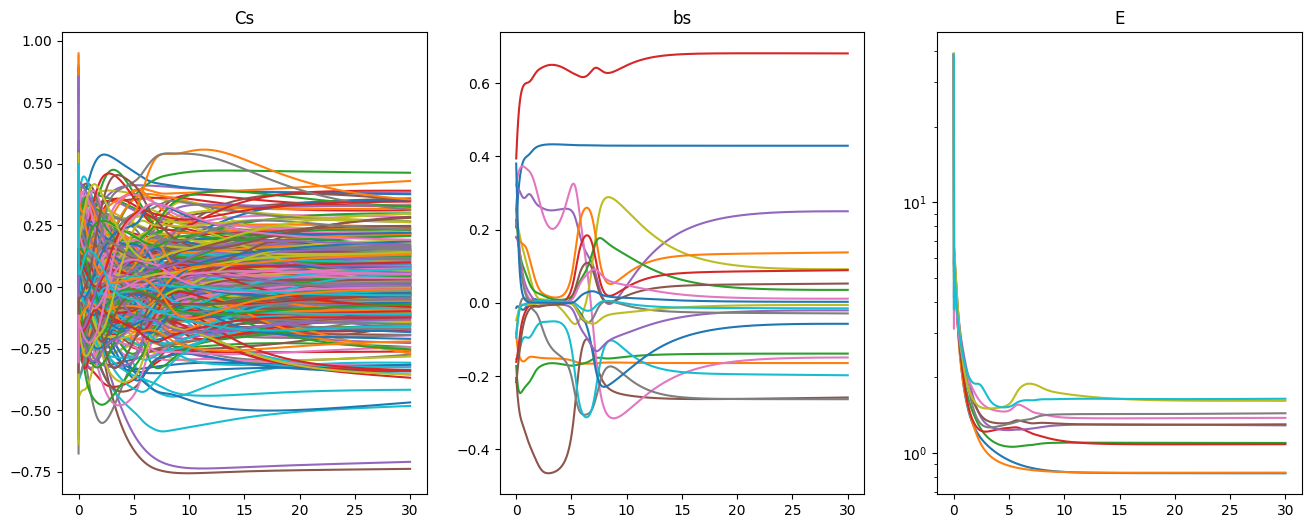

In [13]:
print(f"Final energy: {Es[-1]}")
#print(f"Max overlap coeff (ideally zero): {np.abs(np.max(b_f.T@b_f-np.eye(num_mctdhf_orbitals)))}")

plot_Cbe(ts, Cs, bs, Es)

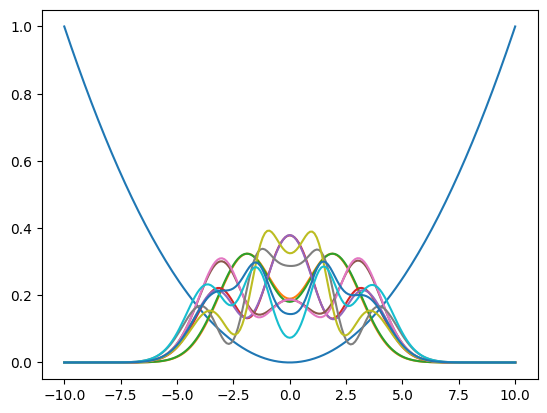

In [14]:
plt.plot(x, pot(x)/np.max(pot(x)), label='Scaled potential')
plt.plot(x, np.real(mctdhf.calculate_particle_densities(bs[-1], Cs[-1], spf).T))
plt.show()

Real time evolution

In [15]:
ht = (x[1]-x[0])*contract('ij, j, kj -> ik', spf.conj(), x, spf)

@jit
def h_t(t, ht=ht):
    return ht*jnp.sin(2*t)

In [16]:
mctdhf_rt = get_MCTDHF(h, h_t, g, num_mctdhf_orbitals, 
                num_spatial_orbitals, num_alpha_electrons, 
                num_beta_electrons, num_states, imag_time=False)

dt = 1e-2
integrator = get_runge_kutta_4_solver(mctdhf_rt, dt)
num_steps = int(4*2*np.pi/(0.25*8*dt))

ts_rt, Es_rt, Cs_rt, bs_rt = mctdhf_rt.integrate(integrator, num_steps=num_steps, t_init = 0, 
                                                b_init = jnp.array(bs[-1]), C_init = jnp.array(Cs[-1]))

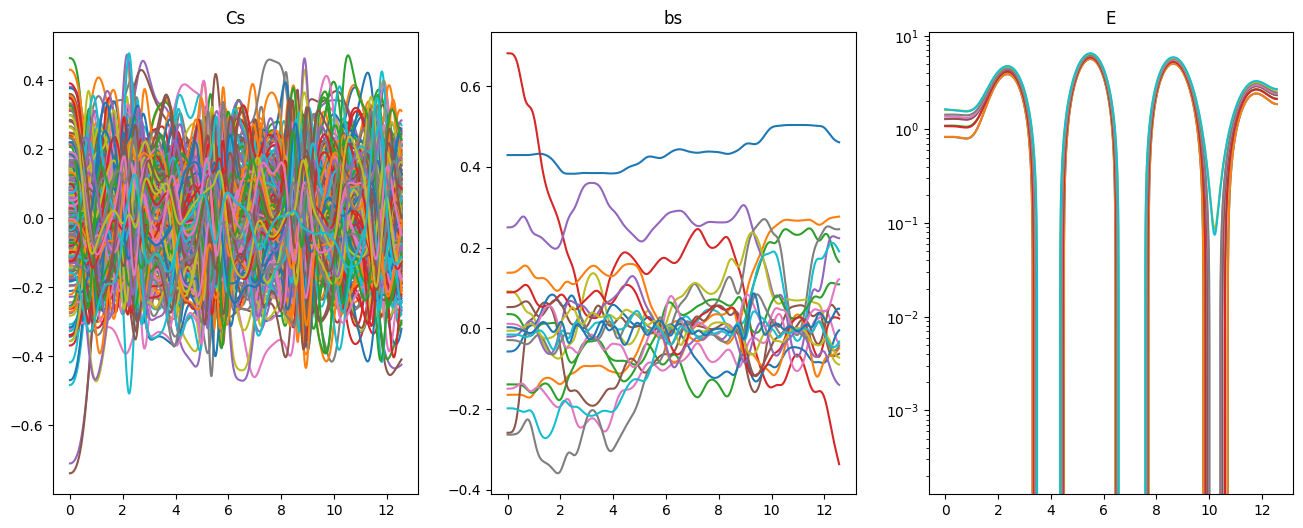

In [17]:
plot_Cbe(ts_rt, Cs_rt, bs_rt, Es_rt)

In [18]:
overlap = [mctdhf_rt.calculate_overlap(bs[-1], Cs[-1], b, C) for b,C in zip(bs_rt, Cs_rt)]

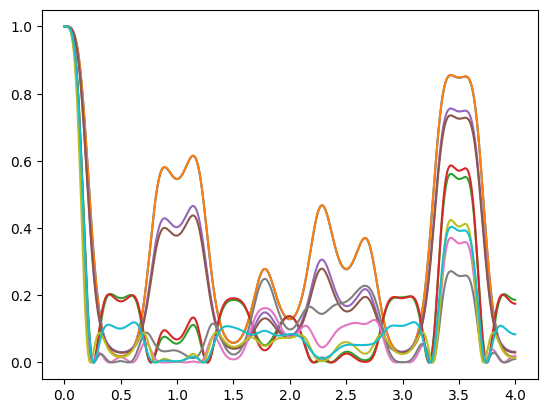

In [19]:
plt.plot(np.array(ts_rt)*0.25*8/(2*np.pi), np.abs(overlap)**2)
plt.show()

## Compare with Zhangellini

In [22]:
dt = 1e-2
num_steps = int(4*2*np.pi/(0.25*8*dt))

Ms = [1,2,3,4]

particle_densities = np.zeros((len(Ms), len(x)))
overlaps = np.zeros((len(Ms), num_steps+1))
gs_energies = np.zeros_like(Ms, np.double)

for i,M in enumerate(Ms):

    mctdhf = get_MCTDHF(h, lambda t: 0, g, M, 
                    num_spatial_orbitals, num_alpha_electrons, 
                    num_beta_electrons, imag_time=True)

    ts, Es, Cs, bs = mctdhf.integrate(num_steps = 5000, dt = 1e-2)
    particle_densities[i,:] = mctdhf.calculate_particle_density(bs[-1], Cs[-1], spf)
    gs_energies[i] = np.real(np.array(Es[-1]))

    mctdhf_rt = get_MCTDHF(h, h_t, g, M, 
                num_spatial_orbitals, num_alpha_electrons, 
                num_beta_electrons, imag_time=False)


    ts_rt, Es_rt, Cs_rt, bs_rt = mctdhf_rt.integrate(num_steps = num_steps, dt = dt, t_init = 0, 
                                                b_init = jnp.array(bs[-1]), C_init = jnp.array(Cs[-1]))

    overlaps[i,:] = np.abs(np.array([mctdhf.calculate_overlap(bs[-1], Cs[-1], b, C) for b,C in zip(bs_rt, Cs_rt)]))**2

Ground state energies
M=1: 1.1796600818634033
M=2: 0.8594634532928467
M=3: 0.8325561285018921
M=4: 0.8314194083213806


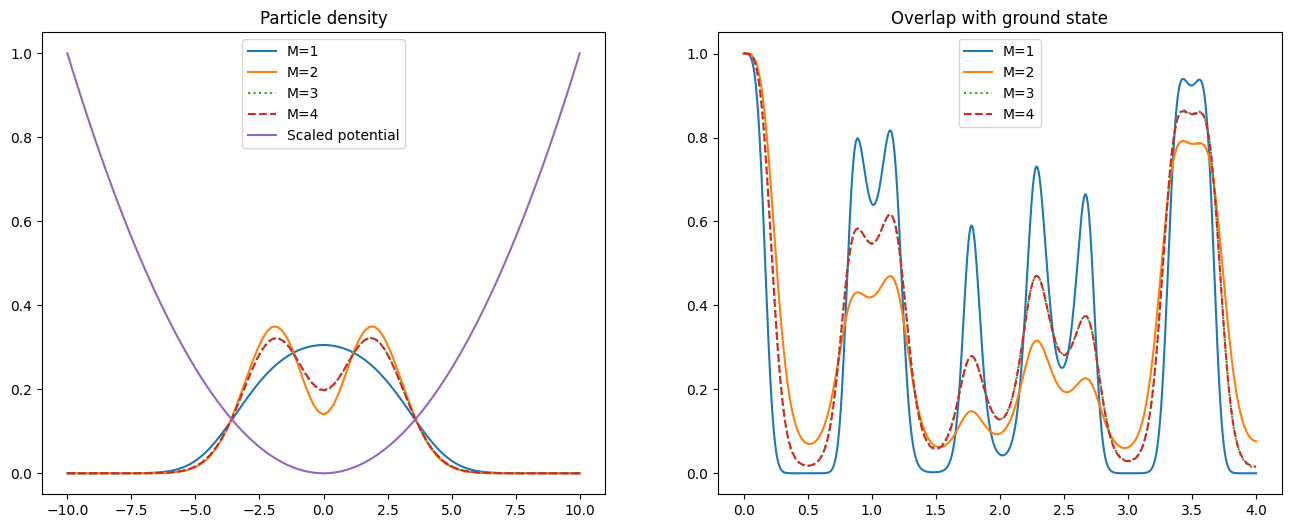

In [23]:
t = np.linspace(0, 4, num_steps+1)
styles = ['-', '-', ':', '--']


fig, axs = plt.subplots(1, 2, figsize=(16,6))

print("Ground state energies")
for i,M in enumerate(Ms):
    print(f'M={M}: {gs_energies[i]}')
    axs[0].plot(x, particle_densities[i], label=f'M={M}', ls=styles[i])
    axs[1].plot(t, overlaps[i], label=f'M={M}', ls=styles[i])


axs[0].plot(x, pot(x)/np.max(pot(x)), label='Scaled potential')

axs[0].set_title('Particle density')
axs[1].set_title('Overlap with ground state')

for a in axs:
    a.legend()
plt.show()
